# AR Predictability vs Spectrum Decay

This notebook reconnects the offline eigenspectrum analysis back to the original LeaRS-style AR idea.

For each trajectory it computes:
1. a power-law covariance spectrum decay exponent,
2. an AR next-step prediction error,
3. the relationship of both to success/failure.

It supports two modes:
- load an existing AR checkpoint,
- or train a small AR model offline from the current buffer and use it immediately.

AR training data in this notebook:
- if `AR_CHECKPOINT is None` and `TRAIN_AR_IF_MISSING = True`, the notebook trains a small AR model on the **same run** loaded from `OUTPUT_DIR`;
- it trains on the extracted analysis sequences in `samples`, so with `USE_REASONING_SPAN = True` this is the reasoning span when available, otherwise the full response trajectory;
- it uses at most `AR_MAX_SAMPLES` trajectories from that run.


In [45]:
from pathlib import Path
import json
import random
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import torch
import math

from research.ar import ARTrainer, ARScorer
from research.buffer import ParquetLatentBuffer
from research.config import ARConfig
from research.latent.codec import deserialize_latent_tensor

OUTPUT_DIR = Path('/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged')
USE_REASONING_SPAN = True
RANDOM_SEED = 1
MAX_COMPONENTS = 64
MIN_SEQ_LEN = 4


CACHE_DIR = OUTPUT_DIR / 'analysis_cache'
FORCE_RECOMPUTE_SPECTRUM = False
FORCE_RECOMPUTE_AR_ERROR = False

# AR options
AR_CHECKPOINT = None  # set to a .pt path to load an existing scorer
TRAIN_AR_IF_MISSING = True
AR_WORK_DIR = OUTPUT_DIR / 'ar_offline_tmp'
AR_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
AR_MAX_SAMPLES = 4800
# When training locally, the AR model is fit on `samples[:AR_MAX_SAMPLES]` from OUTPUT_DIR.
# With USE_REASONING_SPAN=True, that means reasoning-only sequences when spans are present.
AR_TRAIN_STEPS = 1200
AR_BATCH_SIZE = 16
AR_D_MODEL = 256
AR_N_LAYERS = 2
AR_N_HEADS = 4
AR_DROPOUT = 0.1
AR_MIN_BUFFER_SAMPLES = 64
AR_MAX_SEQ_LEN = 4096

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

def load_jsonl(path: Path):
    rows = []
    with path.open(encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

metadata_path = OUTPUT_DIR / 'metadata.jsonl'
buffer_dir = OUTPUT_DIR / 'buffer'
summary_path = OUTPUT_DIR / 'collection_summary.json'

assert metadata_path.exists(), f'missing metadata: {metadata_path}'
assert buffer_dir.exists(), f'missing buffer: {buffer_dir}'

metadata_rows = load_jsonl(metadata_path)
metadata_by_uid = {row['uid']: row for row in metadata_rows}
print(f'Loaded {len(metadata_rows)} metadata rows from {metadata_path}')
if summary_path.exists():
    print(summary_path.read_text(encoding='utf-8'))

def cache_key(payload):
    msg = json.dumps(payload, sort_keys=True).encode('utf-8')
    return hashlib.md5(msg).hexdigest()[:12]


def load_cache_json(path: Path):
    if not path.exists():
        return {}
    with path.open(encoding='utf-8') as f:
        data = json.load(f)
    return data


def save_cache_json(path: Path, data):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


Loaded 16000 metadata rows from /workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/metadata.jsonl
{
  "input_root": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500",
  "output_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged",
  "num_input_shards": 10,
  "merged_metadata_rows": 16000,
  "buffer_stats": {
    "buffer/total_samples": 16000,
    "buffer/total_shards": 16000,
    "buffer/pending_rows": 0
  },
  "shard_dirs": [
    "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/shard_00",
    "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/shard_01",
    "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/shard_02",
    "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/shard_03",
    "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/shard_04",
    "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/sh

In [46]:
buffer = ParquetLatentBuffer(
    root_dir=str(buffer_dir),
    shard_max_samples=256,
    compression='zstd',
    max_disk_gb=1000.0,
)
print('Buffer stats:', buffer.get_stats())


Buffer stats: {'buffer/total_samples': 16000, 'buffer/total_shards': 16000, 'buffer/pending_rows': 0}


In [47]:
def extract_sequence_for_analysis(row, meta, use_reasoning_span=True):
    seq = deserialize_latent_tensor(
        row['latent_blob'],
        seq_len=int(row['response_length']),
        hidden_dim=int(row['hidden_dim']),
        dtype=str(row['dtype']),
    ).float()

    start = 0
    end = seq.shape[0]
    if use_reasoning_span and meta.get('think_token_start') is not None and meta.get('think_token_end') is not None:
        start = int(meta['think_token_start'])
        end = int(meta['think_token_end'])
        start = max(0, min(start, seq.shape[0]))
        end = max(start + 1, min(end, seq.shape[0]))
    return seq[start:end]


def covariance_eigenspectrum(seq):
    x = seq.numpy().astype(np.float64)
    x = x - x.mean(axis=0, keepdims=True)
    if x.shape[0] < 2:
        return None
    cov = (x.T @ x) / max(1, x.shape[0] - 1)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(eigvals)[::-1]
    # eigvals = np.clip(eigvals, 1e-12, None)
    # set small eigvals to 0
    eigvals[eigvals < 1e-12] = 0.0
    return eigvals


def estimate_powerlaw_exponent(eigvals, max_components=64):
    eigvals = np.asarray(eigvals, dtype=np.float64)
    k = min(len(eigvals), max_components)
    if k < 3:
        return None
    ranks = np.arange(1, k + 1, dtype=np.float64)
    x = np.log(ranks)
    y = np.log(eigvals[:k])
    # remove nan/inf values in y
    valid = np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if len(x) < 3:
        return None
    slope, intercept = np.polyfit(x, y, deg=1)
    return float(-slope)

spectrum_cache_key = cache_key({
    'use_reasoning_span': USE_REASONING_SPAN,
    'max_components': MAX_COMPONENTS,
    'min_seq_len': MIN_SEQ_LEN,
    'metadata_rows': len(metadata_rows),
})
spectrum_cache_path = CACHE_DIR / f'spectrum_cache_{spectrum_cache_key}.json'
spectrum_cache = {} if FORCE_RECOMPUTE_SPECTRUM else load_cache_json(spectrum_cache_path)
print('Spectrum cache path:', spectrum_cache_path)
print('Cached spectrum entries:', len(spectrum_cache))

samples = []
sample_by_uid = {}
train_sequences = []
cache_hits = 0
seen_rows = 0
for row in buffer.iter_rows():
    uid = row['uid']
    meta = metadata_by_uid.get(uid)
    if meta is None:
        continue
    seen_rows += 1
    seq = extract_sequence_for_analysis(row, meta, use_reasoning_span=USE_REASONING_SPAN)
    if seq.shape[0] < MIN_SEQ_LEN:
        del seq
        continue
    cached = spectrum_cache.get(uid)
    if cached is not None:
        decay_rate = float(cached['decay_rate']) if cached.get('decay_rate') is not None else None
        top_eigvals = np.asarray(cached.get('top_eigvals', []), dtype=np.float64)
        cache_hits += 1
    else:
        eigvals = covariance_eigenspectrum(seq)
        if eigvals is None:
            del seq
            continue
        decay_rate = estimate_powerlaw_exponent(eigvals, max_components=MAX_COMPONENTS)
        if decay_rate is None:
            del seq
            continue
        top_eigvals = eigvals[:10]
        spectrum_cache[uid] = {
            'decay_rate': float(decay_rate),
            'top_eigvals': [float(x) for x in top_eigvals],
        }
    if decay_rate is None:
        del seq
        continue
    sample = {
        'uid': uid,
        'question_uid': meta.get('question_uid', meta['uid']),
        'sample_idx': int(meta.get('sample_idx', 0)),
        'success': bool(meta['success']),
        'score_accuracy': float(meta['score_accuracy']),
        'response_length': int(meta['response_length']),
        'analysis_length': int(seq.shape[0]),
        'decay_rate': float(decay_rate),
        'top_eigvals': np.asarray(top_eigvals, dtype=np.float64),
    }
    samples.append(sample)
    sample_by_uid[uid] = sample
    if len(train_sequences) < AR_MAX_SAMPLES:
        train_sequences.append(seq)
    else:
        del seq
    print(f'Processed {seen_rows} rows, prepared {len(samples)} samples, cache hits: {cache_hits}', end='\r')

save_cache_json(spectrum_cache_path, spectrum_cache)
print(f'Seen {seen_rows} latent rows that matched metadata')
print(f'Prepared {len(samples)} samples with valid spectra')
print('Spectrum cache hits:', cache_hits)
print('Spectrum cache size after update:', len(spectrum_cache))
print('Training sequences prepared:', len(train_sequences))


Spectrum cache path: /workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/analysis_cache/spectrum_cache_6ba374bb7731.json
Cached spectrum entries: 15998
Seen 16000 latent rows that matched metadata, cache hits: 15998
Prepared 15998 samples with valid spectra
Spectrum cache hits: 15998
Spectrum cache size after update: 15998
Training sequences prepared: 4800


In [48]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [49]:
# Build or load AR scorer.
checkpoint_path = None
if AR_CHECKPOINT is not None:
    checkpoint_path = str(Path(AR_CHECKPOINT).expanduser().resolve())
else:
    candidate = AR_WORK_DIR / 'checkpoints' / 'latest.pt'
    if candidate.exists():
        checkpoint_path = str(candidate)

if checkpoint_path is None and TRAIN_AR_IF_MISSING:
    cfg = ARConfig(
        d_model=AR_D_MODEL,
        n_layers=AR_N_LAYERS,
        n_heads=AR_N_HEADS,
        dropout=AR_DROPOUT,
        lr=1e-4,
        batch_size=AR_BATCH_SIZE,
        train_steps=AR_TRAIN_STEPS,
        min_buffer_samples=AR_MIN_BUFFER_SAMPLES,
        device=AR_DEVICE,
        max_seq_len=AR_MAX_SEQ_LEN,
        train_every_n_steps=1,
    )
    trainer = ARTrainer(config=cfg, work_dir=str(AR_WORK_DIR))
    out = trainer.train_from_sequences(train_sequences, global_step=0)
    if out is None:
        raise RuntimeError('Not enough samples to train AR model')
    checkpoint_path = out.checkpoint_path
    print('Trained AR checkpoint:', checkpoint_path)
    print('AR train loss:', out.train_loss)

assert checkpoint_path is not None, 'Set AR_CHECKPOINT or enable TRAIN_AR_IF_MISSING'
scorer = ARScorer.load_from_checkpoint(checkpoint_path, device=AR_DEVICE)
print('Loaded AR scorer from', checkpoint_path)
print('Scorer meta:', scorer.meta)
del train_sequences


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Loaded AR scorer from /workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/ar_offline_tmp/checkpoints/latest.pt
Scorer meta: ScorerMeta(checkpoint_path='/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/ar_offline_tmp/checkpoints/latest.pt', global_step=0, train_loss=5.796052144527435)


In [50]:
def score_sequence_mean_error(seq, scorer):
    latents = seq.unsqueeze(0)
    response_mask = torch.ones((1, seq.shape[0]), dtype=torch.bool)
    errors = scorer.score(latents, response_mask=response_mask).detach().cpu().numpy()[0]
    valid = errors[1:]  # token 0 has no next-step target
    if valid.size == 0:
        return None
    return float(valid.mean())

ar_cache_key = cache_key({
    'checkpoint_path': checkpoint_path,
    'use_reasoning_span': USE_REASONING_SPAN,
    'sample_uids': [s['uid'] for s in samples[:32]],
    'n_samples': len(samples),
})
ar_cache_path = CACHE_DIR / f'ar_error_cache_{ar_cache_key}.json'
ar_cache = {} if FORCE_RECOMPUTE_AR_ERROR else load_cache_json(ar_cache_path)
print('AR cache path:', ar_cache_path)
print('Cached AR entries:', len(ar_cache))

cache_hits = 0
missing_uids = set()
for sample in samples:
    cached = ar_cache.get(sample['uid'])
    if cached is not None:
        sample['ar_error'] = float(cached['ar_error']) if cached.get('ar_error') is not None else None
        cache_hits += 1
    else:
        missing_uids.add(sample['uid'])

print('AR cache hits:', cache_hits)
print('Need to score uncached samples:', len(missing_uids))

if missing_uids:
    for row in buffer.iter_rows():
        uid = row['uid']
        if uid not in missing_uids:
            continue
        meta = metadata_by_uid.get(uid)
        if meta is None:
            continue
        seq = extract_sequence_for_analysis(row, meta, use_reasoning_span=USE_REASONING_SPAN)
        if seq.shape[0] < MIN_SEQ_LEN:
            ar_cache[uid] = {'ar_error': None}
            sample_by_uid[uid]['ar_error'] = None
            missing_uids.remove(uid)
            del seq
            continue
        value = score_sequence_mean_error(seq, scorer)
        ar_cache[uid] = {'ar_error': None if value is None else float(value)}
        sample_by_uid[uid]['ar_error'] = value
        missing_uids.remove(uid)
        del seq
        if not missing_uids:
            break

save_cache_json(ar_cache_path, ar_cache)
samples = [s for s in samples if s.get('ar_error') is not None]
print('Samples with AR error:', len(samples))
print('AR cache size after update:', len(ar_cache))


AR cache path: /workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/analysis_cache/ar_error_cache_7c57cc95d389.json
Cached AR entries: 15998
AR cache hits: 15998
Need to score uncached samples: 0
Samples with AR error: 15998
AR cache size after update: 15998


In [51]:
def summarize(values):
    arr = np.asarray(values, dtype=np.float64)
    return {
        'n': int(arr.size),
        'mean': float(arr.mean()) if arr.size else None,
        'std': float(arr.std()) if arr.size else None,
        'min': float(arr.min()) if arr.size else None,
        'max': float(arr.max()) if arr.size else None,
    }

success_ar = [s['ar_error'] for s in samples if s['success']]
failure_ar = [s['ar_error'] for s in samples if not s['success']]
success_decay = [s['decay_rate'] for s in samples if s['success']]
failure_decay = [s['decay_rate'] for s in samples if not s['success']]

print('Success AR error stats:', summarize(success_ar))
print('Failure AR error stats:', summarize(failure_ar))
print('Success decay stats:', summarize(success_decay))
print('Failure decay stats:', summarize(failure_decay))

Success AR error stats: {'n': 12880, 'mean': 5.819153155728897, 'std': 0.915642156054572, 'min': 3.3275160789489746, 'max': 8.622261047363281}
Failure AR error stats: {'n': 3118, 'mean': 4.822807225835407, 'std': 0.8103170825366854, 'min': 2.9036061763763428, 'max': 7.777430534362793}
Success decay stats: {'n': 12880, 'mean': 1.0974434715628802, 'std': 0.07395455375278731, 'min': 0.8784879668246839, 'max': 5.5859413386586745}
Failure decay stats: {'n': 3118, 'mean': 1.1542777984242865, 'std': 0.06531258076642181, 'min': 0.9593454061770542, 'max': 1.5518096495303118}


Pearson correlation(decay_rate, ar_error): -0.6402901005120354


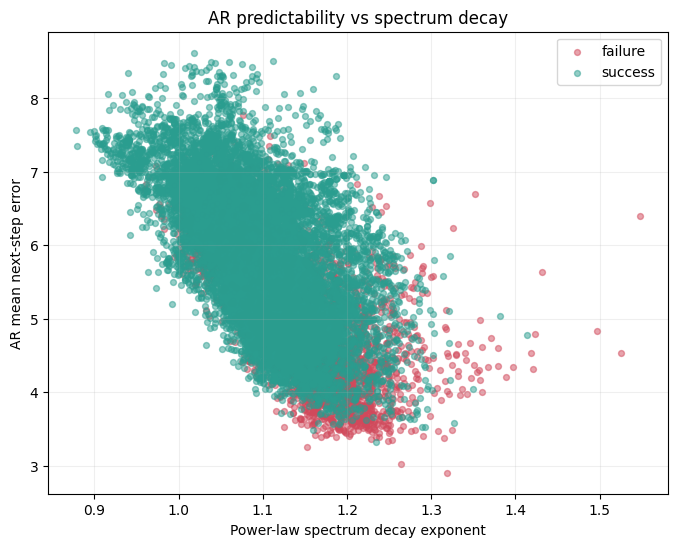

In [52]:
# Correlation between AR error and spectrum decay.
x = np.asarray([s['decay_rate'] for s in samples], dtype=np.float64)
y = np.asarray([s['ar_error'] for s in samples], dtype=np.float64)
labels = np.asarray([1 if s['success'] else 0 for s in samples], dtype=np.int64)

# remove outlier of decay_rate
valid = x < np.percentile(x, 99.99)  # keep decay_rate below 99th percentile
x = x[valid]
y = y[valid]
labels = labels[valid]

corr = np.corrcoef(x, y)[0, 1]
print('Pearson correlation(decay_rate, ar_error):', float(corr))

plt.figure(figsize=(8, 6))
failure = labels == 0
success = labels == 1
if failure.any():
    plt.scatter(x[failure], y[failure], s=18, alpha=0.5, c='#d1495b', label='failure')
if success.any():
    plt.scatter(x[success], y[success], s=18, alpha=0.5, c='#2a9d8f', label='success')
plt.xlabel('Power-law spectrum decay exponent')
plt.ylabel('AR mean next-step error')
plt.title('AR predictability vs spectrum decay')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Pairwise correlations:
Response length vs Analysis length: Pearson=1.0000, Spearman=1.0000
Response length vs Power-law decay: Pearson=0.4894, Spearman=0.6336
Response length vs AR error: Pearson=-0.7191, Spearman=-0.8753
Analysis length vs Power-law decay: Pearson=0.4894, Spearman=0.6336
Analysis length vs AR error: Pearson=-0.7191, Spearman=-0.8753
Power-law decay vs AR error: Pearson=-0.5600, Spearman=-0.6559


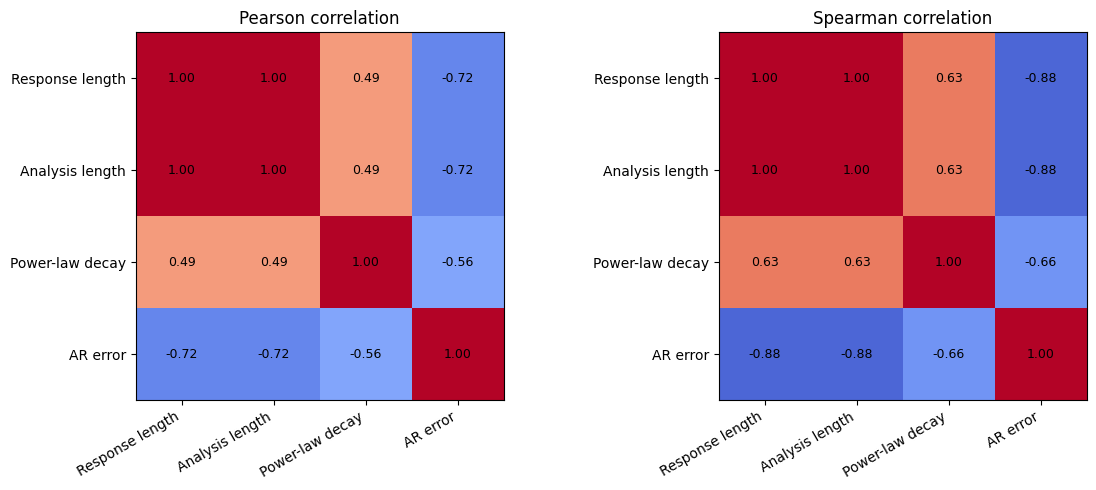

In [53]:
# Correlation analysis across length, decay, and AR error.
def rankdata_average(a):
    a = np.asarray(a, dtype=np.float64)
    order = np.argsort(a, kind='mergesort')
    ranks = np.empty(len(a), dtype=np.float64)
    i = 0
    while i < len(a):
        j = i + 1
        while j < len(a) and a[order[j]] == a[order[i]]:
            j += 1
        avg_rank = 0.5 * (i + j - 1) + 1.0
        ranks[order[i:j]] = avg_rank
        i = j
    return ranks

def spearman_corr(x, y):
    rx = rankdata_average(x)
    ry = rankdata_average(y)
    return float(np.corrcoef(rx, ry)[0, 1])

metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law decay'),
    ('ar_error', 'AR error'),
]
metric_arrays = {key: np.asarray([float(s[key]) for s in samples], dtype=np.float64) for key, _ in metric_specs}
labels = [label for _, label in metric_specs]
pearson = np.zeros((len(metric_specs), len(metric_specs)), dtype=np.float64)
spearman = np.zeros_like(pearson)
for i, (key_i, _) in enumerate(metric_specs):
    for j, (key_j, _) in enumerate(metric_specs):
        xi = metric_arrays[key_i]
        xj = metric_arrays[key_j]
        pearson[i, j] = float(np.corrcoef(xi, xj)[0, 1])
        spearman[i, j] = spearman_corr(xi, xj)

print('Pairwise correlations:')
for i in range(len(metric_specs)):
    for j in range(i + 1, len(metric_specs)):
        print(f'{labels[i]} vs {labels[j]}: Pearson={pearson[i, j]:.4f}, Spearman={spearman[i, j]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matrix, title in zip(axes, [pearson, spearman], ['Pearson correlation', 'Spearman correlation']):
    im = ax.imshow(matrix, cmap='coolwarm', vmin=-1.0, vmax=1.0)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center', fontsize=9)
# fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
plt.tight_layout()
plt.show()


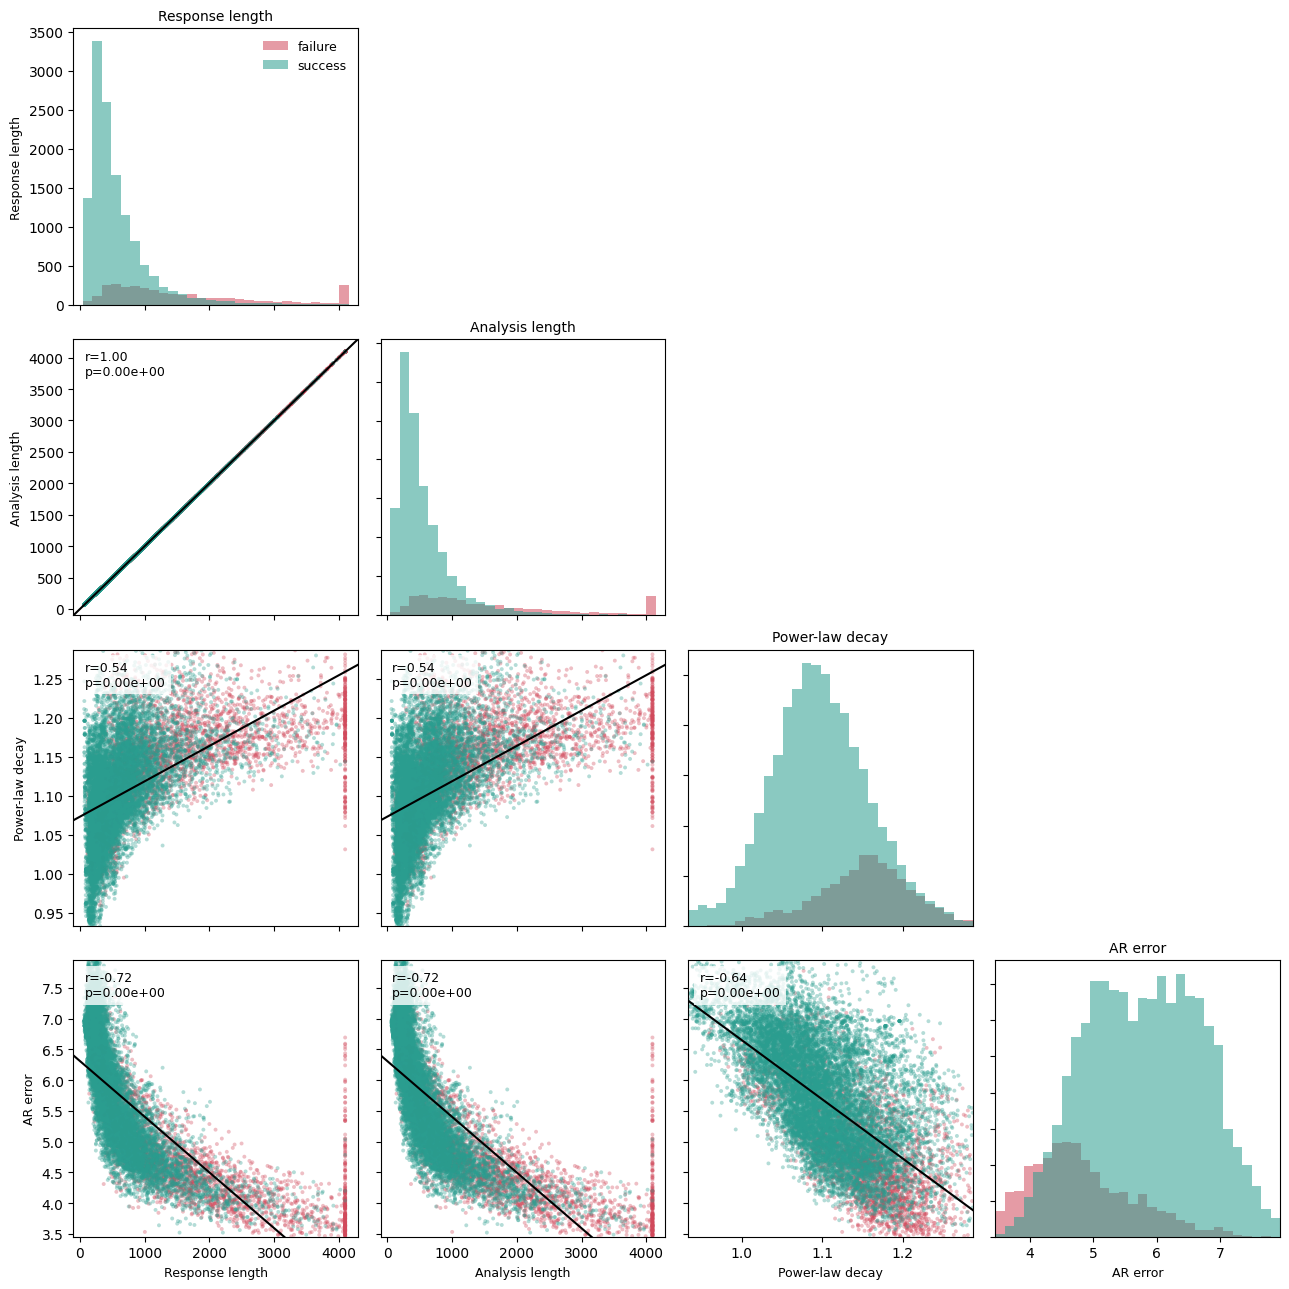

In [54]:
# Lower-triangle regression matrix across scalar metrics.
def pearson_pvalue(r, n):
    if n < 4 or not np.isfinite(r):
        return np.nan
    r = float(np.clip(r, -0.999999, 0.999999))
    z = abs(np.arctanh(r)) * np.sqrt(max(n - 3, 1))
    # two-sided normal approximation from Fisher transform
    return float(math.erfc(z / np.sqrt(2.0)))

def robust_limits(x, lo=1.0, hi=99.0, pad_frac=0.05):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (0.0, 1.0)
    lo_v, hi_v = np.percentile(x, [lo, hi])
    if not np.isfinite(lo_v) or not np.isfinite(hi_v):
        lo_v, hi_v = float(np.min(x)), float(np.max(x))
    if hi_v <= lo_v:
        lo_v, hi_v = float(np.min(x)), float(np.max(x))
    span = hi_v - lo_v
    if span <= 0:
        span = max(abs(lo_v), 1.0) * pad_frac
    pad = span * pad_frac
    return (float(lo_v - pad), float(hi_v + pad))

metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law decay'),
    ('ar_error', 'AR error'),
]
metric_arrays = {key: np.asarray([float(s[key]) for s in samples], dtype=np.float64) for key, _ in metric_specs}
metric_limits = {key: robust_limits(vals) for key, vals in metric_arrays.items()}
success_mask = np.asarray([bool(s['success']) for s in samples], dtype=bool)
failure_mask = ~success_mask
n_metrics = len(metric_specs)
fig, axes = plt.subplots(n_metrics, n_metrics, figsize=(13, 13))
for i in range(n_metrics):
    for j in range(n_metrics):
        ax = axes[i, j]
        if i < j:
            ax.axis('off')
            continue
        key_x, label_x = metric_specs[j]
        key_y, label_y = metric_specs[i]
        x = metric_arrays[key_x]
        y = metric_arrays[key_y]
        if i == j:
            bins = np.linspace(metric_limits[key_x][0], metric_limits[key_x][1], 31)
            if failure_mask.any():
                ax.hist(x[failure_mask], bins=bins, color='#d1495b', alpha=0.55, label='failure')
            if success_mask.any():
                ax.hist(x[success_mask], bins=bins, color='#2a9d8f', alpha=0.55, label='success')
            ax.set_xlim(*metric_limits[key_x])
            ax.set_title(label_x, fontsize=10)
            if i == 0 and j == 0:
                ax.legend(frameon=False, fontsize=9)
        else:
            valid = (
                np.isfinite(x) & np.isfinite(y) &
                (x >= metric_limits[key_x][0]) & (x <= metric_limits[key_x][1]) &
                (y >= metric_limits[key_y][0]) & (y <= metric_limits[key_y][1])
            )
            x_plot = x[valid]
            y_plot = y[valid]
            success_plot = success_mask[valid]
            failure_plot = failure_mask[valid]
            if failure_plot.any():
                ax.scatter(x_plot[failure_plot], y_plot[failure_plot], s=8, c='#d1495b', alpha=0.35, edgecolors='none')
            if success_plot.any():
                ax.scatter(x_plot[success_plot], y_plot[success_plot], s=8, c='#2a9d8f', alpha=0.35, edgecolors='none')
            if x_plot.size >= 2:
                coeffs = np.polyfit(x_plot, y_plot, deg=1)
                xs = np.linspace(metric_limits[key_x][0], metric_limits[key_x][1], 100)
                ys = coeffs[0] * xs + coeffs[1]
                ax.plot(xs, ys, color='black', lw=1.5)
                r = float(np.corrcoef(x_plot, y_plot)[0, 1])
                pval = pearson_pvalue(r, len(x_plot))
                ax.text(0.04, 0.96, f'r={r:.2f}\np={pval:.2e}', transform=ax.transAxes, va='top', ha='left', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            ax.set_xlim(*metric_limits[key_x])
            ax.set_ylim(*metric_limits[key_y])
        if i == n_metrics - 1:
            ax.set_xlabel(label_x, fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(label_y, fontsize=9)
        else:
            ax.set_yticklabels([])
plt.tight_layout()
plt.show()


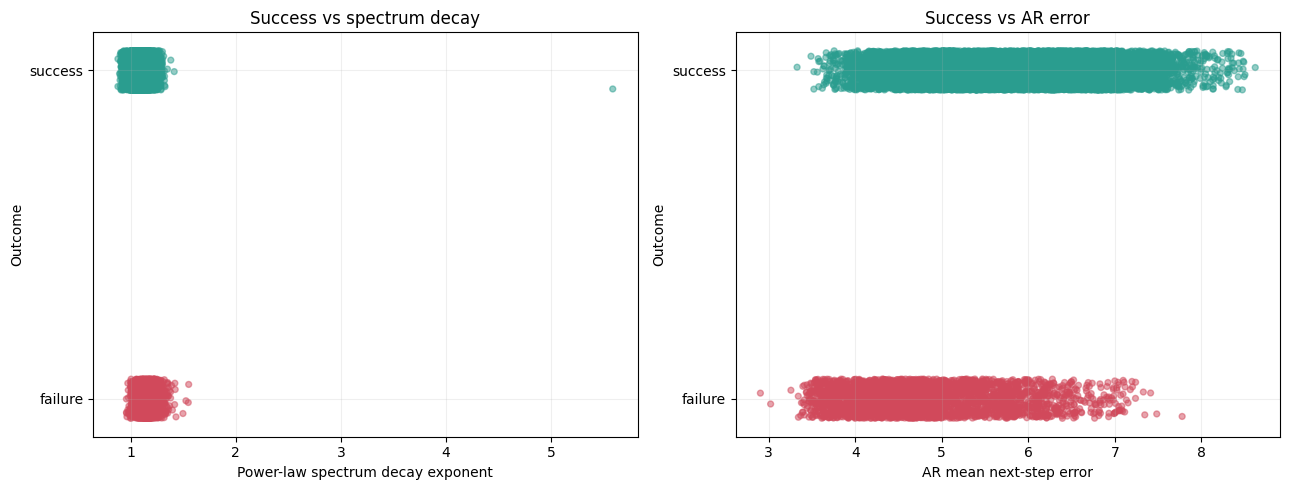

In [55]:
# Success vs AR error and success vs decay.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

y_outcome = np.asarray([1.0 if s['success'] else 0.0 for s in samples], dtype=np.float64)
y_jitter = y_outcome + np.random.uniform(-0.06, 0.06, size=len(y_outcome))

axes[0].scatter(np.asarray([s['decay_rate'] for s in samples]), y_jitter, c=np.where(y_outcome > 0.5, '#2a9d8f', '#d1495b'), s=18, alpha=0.5)
axes[0].set_yticks([0, 1], ['failure', 'success'])
axes[0].set_xlabel('Power-law spectrum decay exponent')
axes[0].set_ylabel('Outcome')
axes[0].set_title('Success vs spectrum decay')
axes[0].grid(alpha=0.2)

axes[1].scatter(np.asarray([s['ar_error'] for s in samples]), y_jitter, c=np.where(y_outcome > 0.5, '#2a9d8f', '#d1495b'), s=18, alpha=0.5)
axes[1].set_yticks([0, 1], ['failure', 'success'])
axes[1].set_xlabel('AR mean next-step error')
axes[1].set_ylabel('Outcome')
axes[1].set_title('Success vs AR error')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [56]:
def cliffs_delta(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.size == 0 or y.size == 0:
        return None
    total = 0
    for xv in x:
        total += np.sum(xv > y) - np.sum(xv < y)
    return float(total / (x.size * y.size))


def permutation_mean_diff(x, y, n_perm=2000, seed=1):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    observed = float(x.mean() - y.mean())
    pooled = np.concatenate([x, y]).copy()
    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        xp = pooled[:x.size]
        yp = pooled[x.size:]
        diff = xp.mean() - yp.mean()
        if abs(diff) >= abs(observed):
            count += 1
    p = (count + 1) / (n_perm + 1)
    return observed, p

for name, sx, fx in [
    ('decay_rate', success_decay, failure_decay),
    ('ar_error', success_ar, failure_ar),
]:
    obs, pval = permutation_mean_diff(sx, fx, n_perm=2000, seed=RANDOM_SEED)
    print(name)
    print('  mean(success) - mean(failure):', obs)
    print('  cliffs_delta(success, failure):', cliffs_delta(sx, fx))
    print('  permutation p-value:', pval)

decay_rate
  mean(success) - mean(failure): -0.056834326861406215
  cliffs_delta(success, failure): -0.4909598245411336
  permutation p-value: 0.0004997501249375312
ar_error
  mean(success) - mean(failure): 0.99634592989349
  cliffs_delta(success, failure): 0.5825397461742875
  permutation p-value: 0.0004997501249375312


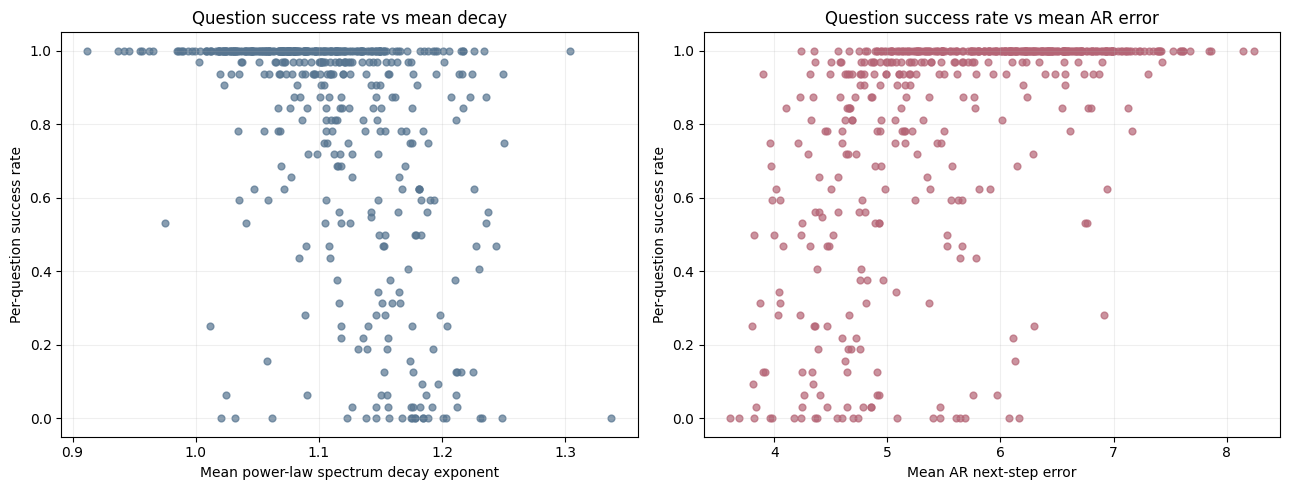

In [57]:
# Question-level summary: does mean decay or mean AR error track question difficulty?
by_question = {}
for item in samples:
    by_question.setdefault(item['question_uid'], []).append(item)

question_rows = []
for qid, group in by_question.items():
    succ = np.asarray([1.0 if x['success'] else 0.0 for x in group], dtype=np.float64)
    dec = np.asarray([x['decay_rate'] for x in group], dtype=np.float64)
    ar = np.asarray([x['ar_error'] for x in group], dtype=np.float64)
    question_rows.append({
        'question_uid': qid,
        'n_samples': len(group),
        'success_rate': float(succ.mean()),
        'mean_decay_rate': float(dec.mean()),
        'std_decay_rate': float(dec.std()),
        'mean_ar_error': float(ar.mean()),
        'std_ar_error': float(ar.std()),
    })

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter([r['mean_decay_rate'] for r in question_rows], [r['success_rate'] for r in question_rows], s=24, alpha=0.7, c='#577590')
axes[0].set_xlabel('Mean power-law spectrum decay exponent')
axes[0].set_ylabel('Per-question success rate')
axes[0].set_title('Question success rate vs mean decay')
axes[0].grid(alpha=0.2)

axes[1].scatter([r['mean_ar_error'] for r in question_rows], [r['success_rate'] for r in question_rows], s=24, alpha=0.7, c='#b56576')
axes[1].set_xlabel('Mean AR next-step error')
axes[1].set_ylabel('Per-question success rate')
axes[1].set_title('Question success rate vs mean AR error')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Side-by-Side Metric Comparison

This section compares `response_length`, `analysis_length`, `decay_rate`, and `ar_error` using the same descriptive views so you can see whether spectrum/AR effects are stronger or different than plain length effects.


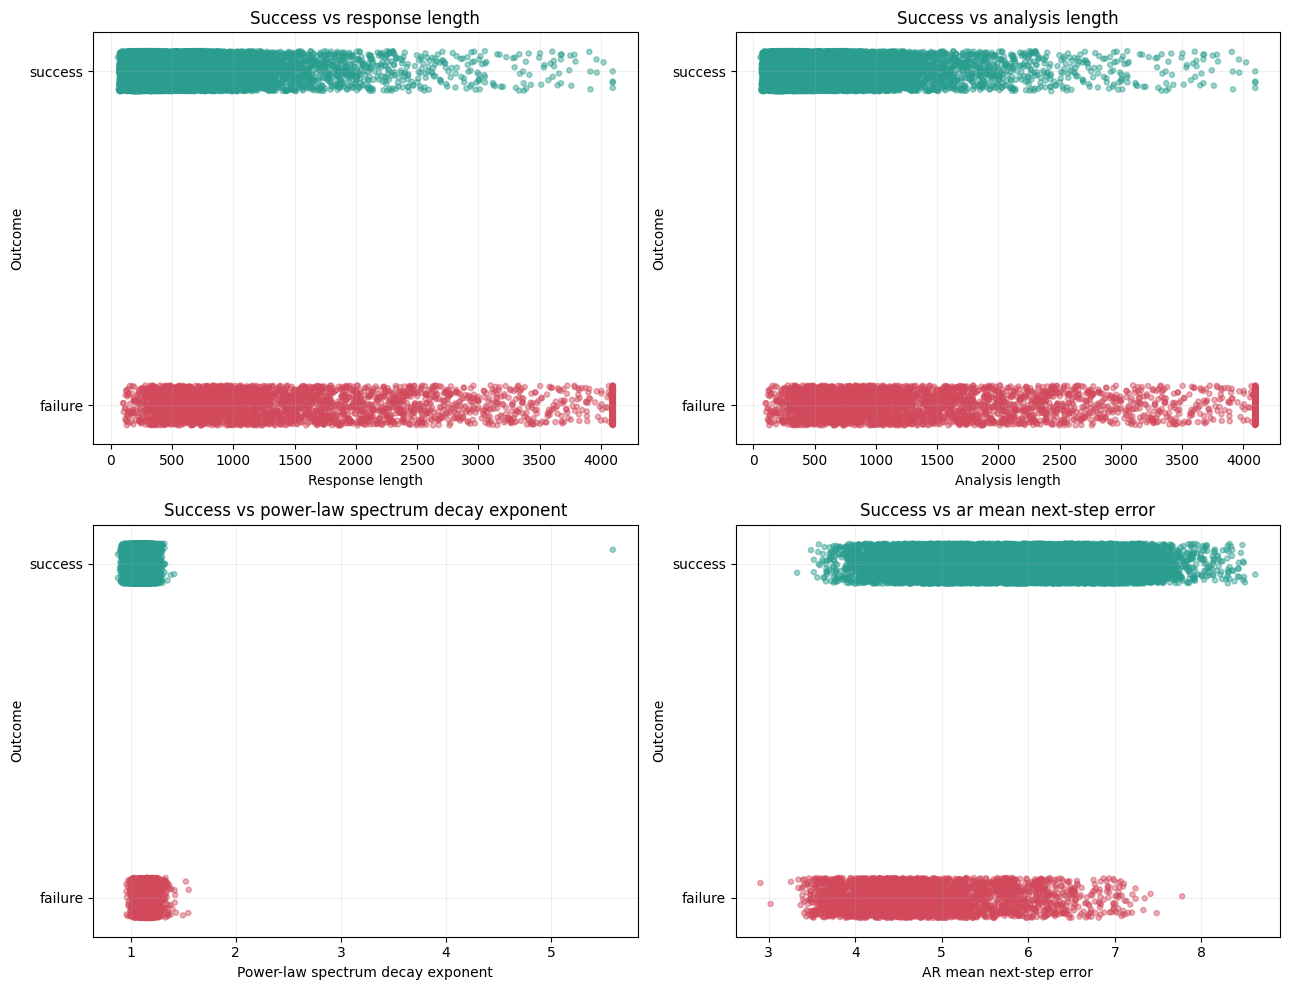

In [58]:
metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law spectrum decay exponent'),
    ('ar_error', 'AR mean next-step error'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
outcome = np.asarray([1.0 if s['success'] else 0.0 for s in samples], dtype=np.float64)
outcome_jitter = outcome + np.random.uniform(-0.06, 0.06, size=len(outcome))
colors = np.where(outcome > 0.5, '#2a9d8f', '#d1495b')

for ax, (key, label) in zip(axes, metric_specs):
    vals = np.asarray([s[key] for s in samples], dtype=np.float64)
    ax.scatter(vals, outcome_jitter, c=colors, s=14, alpha=0.45)
    ax.set_yticks([0, 1], ['failure', 'success'])
    ax.set_xlabel(label)
    ax.set_ylabel('Outcome')
    ax.set_title(f'Success vs {label.lower()}')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


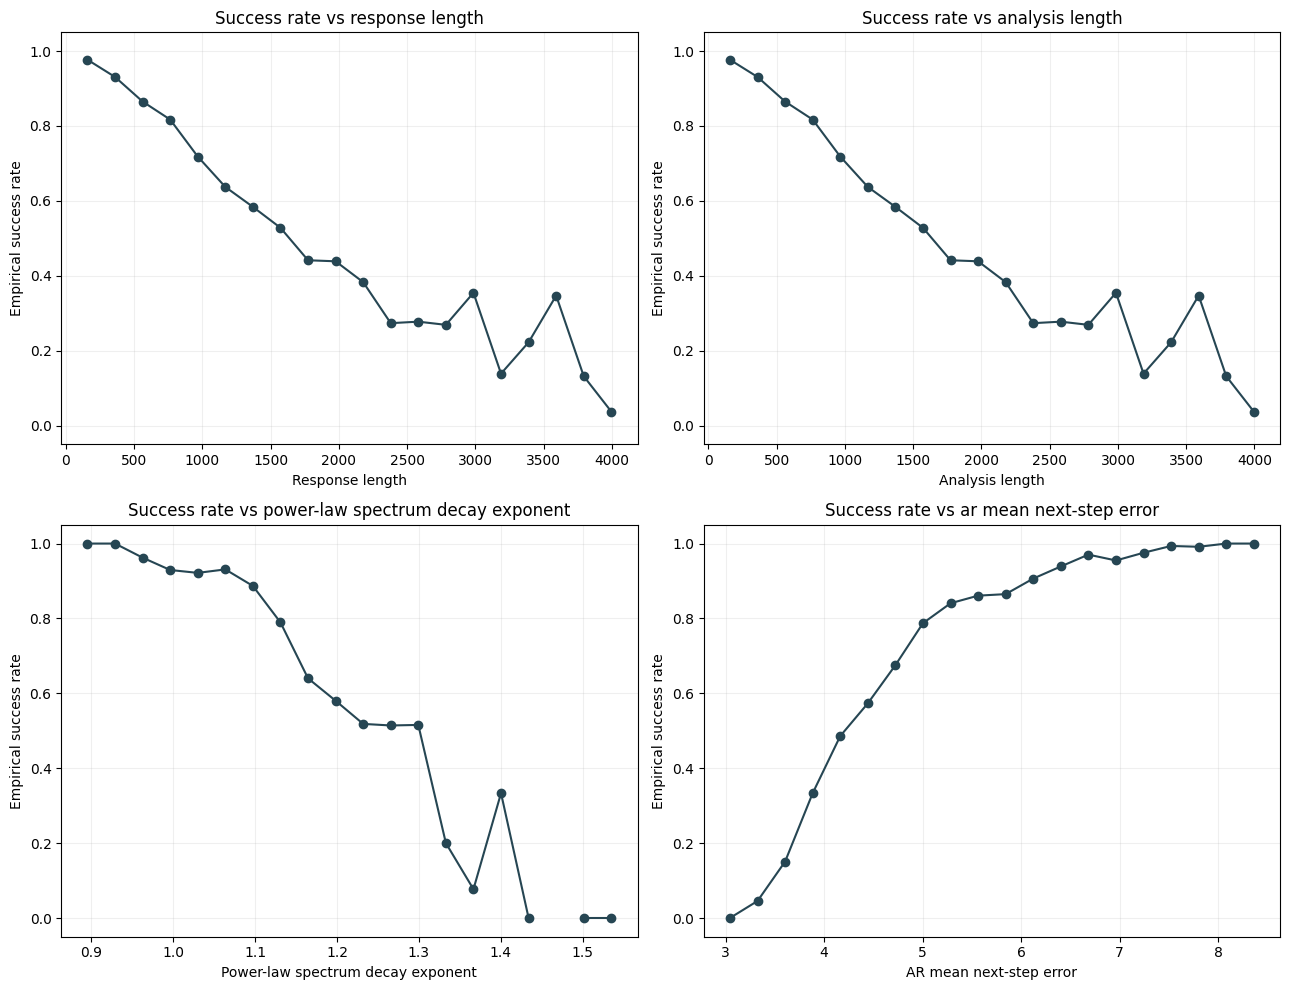

In [67]:
def binned_success_rate_from_values(values, success, n_bins=20):
    x = np.asarray(values, dtype=np.float64)
    y = np.asarray(success, dtype=np.float64)
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rates = []
    counts = []
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        if i == len(edges) - 2:
            mask = (x >= lo) & (x <= hi)
        else:
            mask = (x >= lo) & (x < hi)
        if mask.any():
            rates.append(float(y[mask].mean()))
            counts.append(int(mask.sum()))
        else:
            rates.append(np.nan)
            counts.append(0)
    return centers, np.asarray(rates), np.asarray(counts)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
success01 = np.asarray([1.0 if s['success'] else 0.0 for s in samples], dtype=np.float64)

for ax, (key, label) in zip(axes, metric_specs):
    vals = [s[key] for s in samples]
    # filter out extreme values for better visualization
    vals = np.asarray(vals, dtype=np.float64)
    valid = np.percentile(vals, 99.999)
    vals_valid = vals[vals <= valid]
    success01_valid = success01[vals <= valid]
    centers, rates, counts = binned_success_rate_from_values(vals_valid, success01_valid, n_bins=20)
    ax.plot(centers, rates, marker='o', color='#264653')
    ax.set_xlabel(label)
    ax.set_ylabel('Empirical success rate')
    ax.set_title(f'Success rate vs {label.lower()}')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Within-Question Paired Comparisons

This section compares successful and failed samples **within the same question**. This is the main nonparametric control for question difficulty and avoids assuming an additive model.


In [60]:
by_question = {}
for item in samples:
    by_question.setdefault(item['question_uid'], []).append(item)

paired_metric_gaps = {key: [] for key, _ in metric_specs}
paired_counts = 0
for qid, group in by_question.items():
    succ = [x for x in group if x['success']]
    fail = [x for x in group if not x['success']]
    if not succ or not fail:
        continue
    paired_counts += 1
    for key, _ in metric_specs:
        succ_mean = float(np.mean([x[key] for x in succ]))
        fail_mean = float(np.mean([x[key] for x in fail]))
        paired_metric_gaps[key].append(fail_mean - succ_mean)

print('Questions with both success and failure:', paired_counts)
for key, label in metric_specs:
    vals = np.asarray(paired_metric_gaps[key], dtype=np.float64)
    print(label, summarize(vals))


Questions with both success and failure: 233
Response length {'n': 233, 'mean': 118.12043248841401, 'std': 375.2509723474527, 'min': -989.6742857142858, 'max': 1951.3666666666666}
Analysis length {'n': 233, 'mean': 118.12043248841401, 'std': 375.2509723474527, 'min': -989.6742857142858, 'max': 1951.3666666666666}
Power-law spectrum decay exponent {'n': 233, 'mean': 0.006646567632825896, 'std': 0.029185087418870586, 'min': -0.20846508175919887, 'max': 0.14558433207712573}
AR mean next-step error {'n': 233, 'mean': -0.09942504766624731, 'std': 0.2814199197382492, 'min': -1.7562515658717004, 'max': 0.5362006156675276}


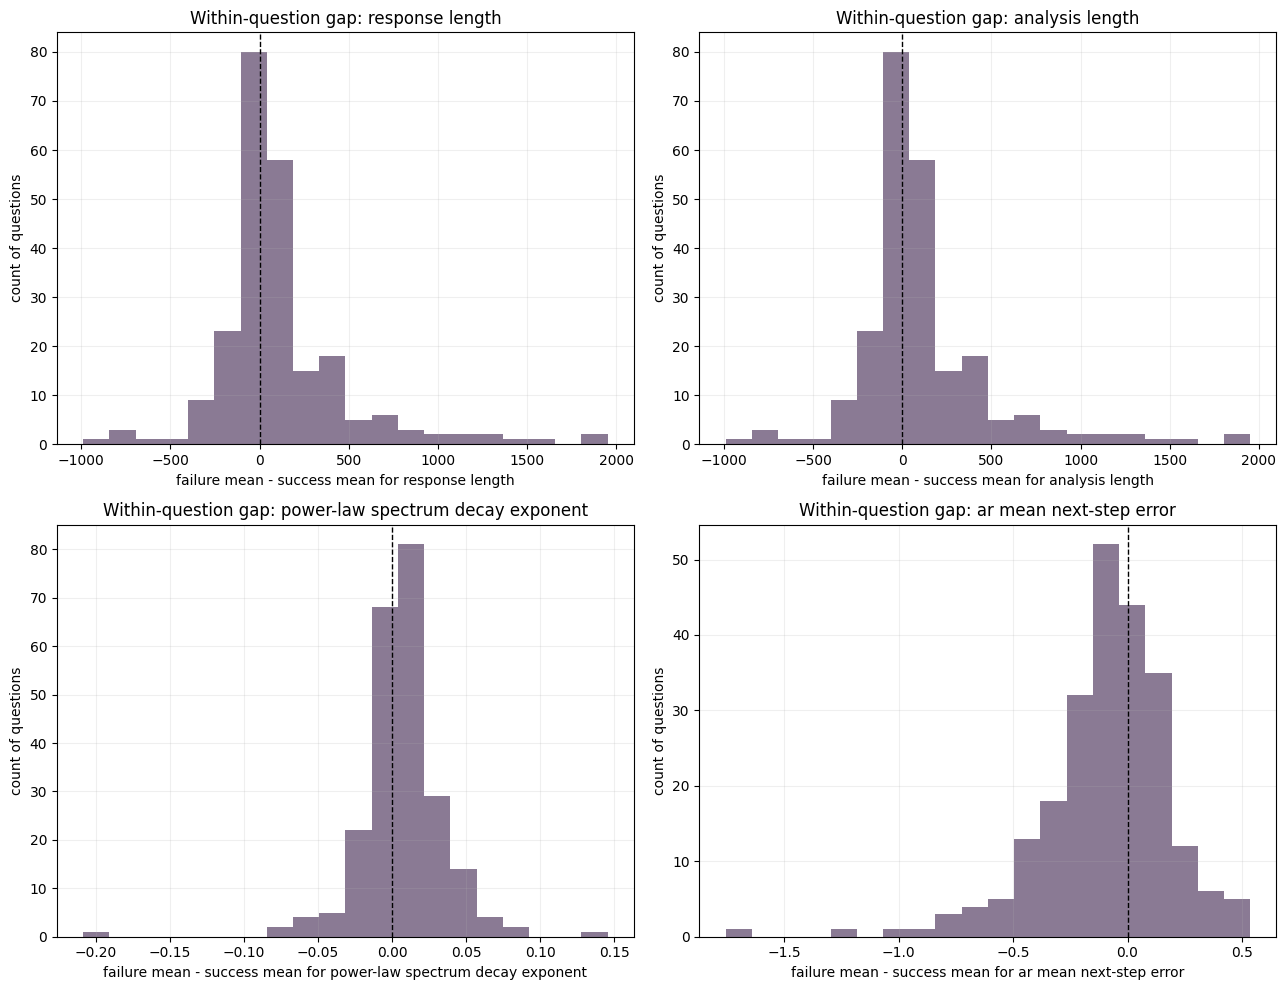

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
for ax, (key, label) in zip(axes, metric_specs):
    vals = np.asarray(paired_metric_gaps[key], dtype=np.float64)
    ax.hist(vals, bins=20, color='#6d597a', alpha=0.8)
    ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel(f'failure mean - success mean for {label.lower()}')
    ax.set_ylabel('count of questions')
    ax.set_title(f'Within-question gap: {label.lower()}')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [62]:
def paired_sign_summary(values, name):
    vals = np.asarray(values, dtype=np.float64)
    pos = int(np.sum(vals > 0))
    neg = int(np.sum(vals < 0))
    zero = int(np.sum(vals == 0))
    print(name)
    print('  positive:', pos)
    print('  negative:', neg)
    print('  zero:', zero)
    print('  mean gap:', float(vals.mean()) if vals.size else None)

for key, label in metric_specs:
    paired_sign_summary(paired_metric_gaps[key], label)


Response length
  positive: 137
  negative: 95
  zero: 1
  mean gap: 118.12043248841401
Analysis length
  positive: 137
  negative: 95
  zero: 1
  mean gap: 118.12043248841401
Power-law spectrum decay exponent
  positive: 145
  negative: 88
  zero: 0
  mean gap: 0.006646567632825896
AR mean next-step error
  positive: 84
  negative: 149
  zero: 0
  mean gap: -0.09942504766624731
